# Empirical Gaussian Processes

This tutorial illustrates the *Empirical Gaussian Process* introduced in ["Empirical Gaussian Processes"](https://arxiv.org/abs/2602.12082) (Lin et al., ICML 2026) on two real one-dimensional forecasting problems: a financial series (the S&P 500 stock-market index) and a climate series (atmospheric CO2 concentration at the Mauna Loa Observatory).

## The idea

A standard Gaussian process (GP) requires the user to *handcraft* a prior mean and covariance (kernel) function that encode beliefs about the function being modeled. The kernel is typically selected from a small set of standard stationary kernels (RBF, Matérn, periodic), and its hyperparameters are fit by maximizing the marginal likelihood. This is limited in flexibility — there is no "one size fits all" kernel — and stationary kernels are poorly suited for *extrapolation* beyond the observed input range.

The Empirical GP instead **estimates the prior mean and covariance functions directly from a corpus of historical observations of the data-generating stochastic process**. Given $S$ independent sample paths $f_1, \dots, f_S$, we estimate the true mean $m = \mathbb{E}[f]$ and covariance function $k = \mathrm{Cov}(f)$ by maximum likelihood,

$$
m_S(\mathbf{x}) = \frac{1}{S}\sum_{i=1}^{S} f_i(\mathbf{x}),
\qquad
k_S(\mathbf{x}, \mathbf{x}') = \frac{1}{S}\sum_{i=1}^{S} \tilde{f}_i(\mathbf{x})\, \tilde{f}_i(\mathbf{x}'),
$$

where $\tilde{f}_i(\mathbf{x}) = f_i(\mathbf{x}) - m(\mathbf{x})$ is the centered sample path. We define the *Empirical GP* as $\mathcal{GP}(m_S, k_S)$. Note that $k_S$ is a valid (positive semi-definite) kernel by construction, since it is a sum of outer products of the centered functions. As $S \to \infty$, the Empirical GP converges to the best Gaussian approximation (in the KL-divergence sense) of the true data-generating process.

The resulting `EmpiricalOneDimensionalMean` and `EmpiricalOneDimensionalKernel` interpolate these empirical statistics to arbitrary query locations and can be dropped into any BoTorch `SingleTaskGP` in place of a handcrafted mean/kernel.

## What this tutorial does

We reproduce the qualitative experiment from the paper's *"Capturing the Behavior of Handcrafted Kernels"* section: without human intervention, the Empirical GP recovers the behavior of kernels that were handcrafted by human experts. Each task consists of extrapolating a *single* time series, so we use sliding windows to extract additional **subseries** that serve as the historical sample paths $f_1, \dots, f_S$ for the Empirical GP; this implicitly assumes self-similarity in the underlying process. For each series we hold out a future horizon and forecast it from a short observed window, comparing two models:

1. an **Empirical GP**, whose prior mean and covariance are estimated from the historical subseries, and
2. a **handcrafted GP** baseline with an expert-designed mean and kernel.

For the financial series the expert model is geometric Brownian motion; for the climate series it is a kernel handcrafted for this dataset by Carl Rasmussen. We then plot both forecasts and report RMSE and negative log-likelihood (NLL) on the held-out horizon.

The integrated white noise kernel (`IntegratedWhiteNoiseKernel`, parameterized by the integration `order`: order 1 is Brownian motion, order 2 is integrated Brownian motion, order 3 is twice-integrated Brownian motion, and so on) and the empirical mean/kernel modules used here are all part of the BoTorch library.

In [1]:
# Install dependencies if we are running in colab
import sys

if "google.colab" in sys.modules:
    %pip install botorch

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.empirical_gps import (
    EmpiricalOneDimensionalKernel,
    EmpiricalOneDimensionalMean,
)
from botorch.models.kernels import IntegratedWhiteNoiseKernel
from gpytorch.constraints import GreaterThan
from gpytorch.kernels import PeriodicKernel, RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean, LinearMean
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.priors import LogNormalPrior
from matplotlib.lines import Line2D
from scipy.stats import norm
from sklearn.metrics import mean_squared_error

torch.set_default_dtype(torch.float64)

SMOKE_TEST = os.environ.get("SMOKE_TEST")

## Loading the data

We load two CSV files that ship with the BoTorch repository under `tutorials/data/`:

- `sap500.csv`: daily S&P 500 index values (we use the `Close` column).
- `co2_daily_mlo.csv`: daily atmospheric CO2 concentration at Mauna Loa (NOAA GML); the file has `#`-prefixed comment lines and no header row, with columns `year, month, day, decimal_date, ppm`.

Both datasets are redistributed under the CC0 license.

In [3]:
def get_data_dir() -> str:
    """Get the directory of the data, which ships with the BoTorch repo.

    Checks if we are in a common part of the BoTorch repository
    (botorch/botorch or botorch/tutorials) and returns the right path.
    """
    if "DATA_LOCATION" in os.environ:
        return os.environ["DATA_LOCATION"] + "/"
    cwd = os.getcwd()
    folder = os.path.basename(cwd)
    # automated tests run from the botorch folder
    if folder == "botorch":
        return os.path.join(cwd, "tutorials/data/")
    # typical case (running from the tutorial folder)
    elif folder == "tutorials":
        return os.path.join(cwd, "data/")
    raise FileNotFoundError("Could not figure out location of the data folder.")


def get_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the financial (S&P 500) and climate (Mauna Loa CO2) data frames."""
    data_dir = get_data_dir()
    financial_df = pd.read_csv(data_dir + "sap500.csv", header="infer")
    # The CO2 file has commented header lines (#) and no column header row.
    climate_df = pd.read_csv(data_dir + "co2_daily_mlo.csv", comment="#", header=None)
    return financial_df, climate_df


financial_df, climate_df = get_data()
print(financial_df.head())
print(climate_df.head())

         Date       Open       High        Low      Close  Volume
0  1927-12-30  17.660000  17.660000  17.660000  17.660000     0.0
1  1928-01-03  17.760000  17.760000  17.760000  17.760000     0.0
2  1928-01-04  17.719999  17.719999  17.719999  17.719999     0.0
3  1928-01-05  17.549999  17.549999  17.549999  17.549999     0.0
4  1928-01-06  17.660000  17.660000  17.660000  17.660000     0.0
      0  1   2          3       4
0  1974  5  19  1974.3781  333.46
1  1974  5  20  1974.3808  333.64
2  1974  5  21  1974.3836  333.50
3  1974  5  22  1974.3863  333.21
4  1974  5  23  1974.3890  333.05


In [4]:
# Financial: parse dates and split into a long training history and a test horizon.
financial_df["Date"] = pd.to_datetime(financial_df["Date"])
financial_train_mask = (financial_df["Date"] >= "1930-01-01") & (
    financial_df["Date"] < "2010-01-01"
)
financial_test_mask = (financial_df["Date"] >= "2010-01-01") & (
    financial_df["Date"] < "2025-01-01"
)
financial_data_train = financial_df[financial_train_mask]["Close"].to_numpy()
financial_data_test = financial_df[financial_test_mask]["Close"].to_numpy()

# Climate: build a date column from the year/month/day columns, then split.
climate_df["Date"] = pd.to_datetime(
    climate_df[[0, 1, 2]].astype(str).agg("-".join, axis=1)
)
climate_data_train = climate_df[
    (climate_df["Date"] >= "1975-01-01") & (climate_df["Date"] < "2010-01-01")
][4].to_numpy()
climate_data_test = climate_df[
    (climate_df["Date"] >= "2010-01-01") & (climate_df["Date"] < "2025-01-01")
][4].to_numpy()

print("financial train/test sizes:", financial_data_train.shape, financial_data_test.shape)
print("climate train/test sizes:", climate_data_train.shape, climate_data_test.shape)

financial train/test sizes: (20093,) (3774,)
climate train/test sizes: (10478,) (4856,)


## Helper functions

Because each task consists of extrapolating a *single* time series, we use a sliding window to extract additional **subseries** that serve as the historical sample paths $f_1, \dots, f_S$ for the Empirical GP. This assumes self-similarity in the underlying process (which holds exactly for, e.g., geometric Brownian motion). `get_historical` slices a training series into overlapping fixed-length subseries; we optionally apply a log transform and/or align each subseries to start at zero (an offset), which reflects the exponential nature of the financial series and makes the subseries directly comparable.

In [5]:
def get_historical(
    data: np.ndarray,
    chunk_size: int = 365,
    stride: int = 1,
    use_log_space: bool = False,
    use_offset: bool = False,
) -> np.ndarray:
    """Slice ``data`` into overlapping, sliding-window subseries of length ``chunk_size``.

    Returns an array of shape ``num_chunks x chunk_size``.
    """
    start_indices = np.arange(0, len(data) - chunk_size + 1, stride)
    # Matrix of indices for easy broadcasting: num_chunks x chunk_size
    indices_matrix = start_indices[:, None] + np.arange(chunk_size)
    chunks = data[indices_matrix]
    if use_log_space:
        chunks = np.log(chunks)
    if use_offset:
        chunks = chunks - chunks[:, 0][:, None]
    return chunks


def calculate_annual_metrics(prices: np.ndarray) -> tuple[float, float]:
    """Estimate the annualized return and volatility of a price series."""
    returns = np.diff(prices) / prices[:-1]
    mean_daily_return = np.mean(returns)
    annual_return = (1 + mean_daily_return) ** 252 - 1
    daily_volatility = np.std(returns)
    annualized_volatility = daily_volatility * np.sqrt(252)
    return annual_return, annualized_volatility

The `get_predictions` helper builds a BoTorch `SingleTaskGP` from a given mean and covariance module and returns posterior predictions on the training and test inputs. It supports an optional log-space transform with an additive offset (so the GP models the de-trended log series and we map predictions back to the original space), a fixed tiny observation noise (used for the Empirical GP, which already captures uncertainty through its empirical covariance), and marginal-likelihood fitting (used for the handcrafted baselines).

In [6]:
def _revert_log_normal(mean: torch.Tensor, var: torch.Tensor):
    """Map the mean/variance of a log-normal back to the original space."""
    reverted_mean = torch.exp(mean + 0.5 * var)
    reverted_var = (var.exp() - 1) * (2 * mean + var).exp()
    return reverted_mean, reverted_var


def _get_likelihood(loc=-4.0, scale=1.0, lower_bound=1e-8, fix_noise=None):
    prior = LogNormalPrior(loc=loc, scale=scale)
    constraint = GreaterThan(lower_bound, initial_value=prior.mode)
    likelihood = GaussianLikelihood(noise_prior=prior, noise_constraint=constraint)
    if fix_noise is not None:
        likelihood.noise = torch.tensor(fix_noise, dtype=torch.float64)
        likelihood.requires_grad_(False)
    return likelihood


def _predict(X, model, use_log_space, offset, observation_noise, n_samples):
    model.eval()
    with torch.no_grad():
        posterior = model.posterior(X, observation_noise=observation_noise)
        pred_mean = posterior.mean.squeeze() + offset
        pred_var = posterior.variance.squeeze()
        if use_log_space:
            pred_mean, pred_var = _revert_log_normal(pred_mean, pred_var)
        pred_std = pred_var.sqrt()

        samples = posterior.rsample(sample_shape=torch.Size([n_samples]))
        samples = samples.squeeze() + offset
        if use_log_space:
            samples = samples.exp()
    return pred_mean, pred_std, samples


def get_predictions(
    train_X,
    train_Y,
    test_X,
    mean_module,
    covar_module,
    fix_noise=None,
    outcome_transform=None,
    use_log_space=False,
    use_offset=False,
    fit_model=False,
    observation_noise=False,
    n_samples=5,
    seed=42,
):
    torch.manual_seed(seed)

    if use_log_space:
        train_Y = train_Y.log()
    offset = train_Y[0] if use_offset else 0.0

    model = SingleTaskGP(
        train_X=train_X[:, None],
        train_Y=train_Y[:, None] - offset,
        likelihood=_get_likelihood(fix_noise=fix_noise),
        mean_module=mean_module,
        covar_module=covar_module,
        input_transform=None,
        outcome_transform=outcome_transform,
    )

    if fit_model:
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_kwargs = {}
        if SMOKE_TEST is not None:
            # Keep the smoke test fast by capping the optimizer iterations.
            fit_kwargs["optimizer_kwargs"] = {"options": {"maxiter": 5}}
        fit_gpytorch_mll(mll, **fit_kwargs)

    pred_mean_train, pred_std_train, samples_train = _predict(
        train_X, model, use_log_space, offset, observation_noise, n_samples
    )
    pred_mean_test, pred_std_test, samples_test = _predict(
        test_X, model, use_log_space, offset, observation_noise, n_samples
    )
    return (
        pred_mean_train,
        pred_std_train,
        samples_train,
        pred_mean_test,
        pred_std_test,
        samples_test,
    )

## Financial series: S&P 500

We forecast the second half of a 252-trading-day (one-year) window from its first half. The **Empirical GP** estimates its prior from overlapping one-year subseries of the 1930–2010 training history, log-transformed and aligned to start at zero. The **handcrafted** baseline is geometric Brownian motion, the canonical expert model for stock prices, which assumes the log price follows a random walk with drift, $dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$, where $S_t$ is the price at time $t$, $\mu$ is the expected rate of return, $\sigma$ is the volatility, and $W_t$ is Brownian motion. We estimate $\mu$ and $\sigma$ on the same historical data used by the Empirical GP. In de-trended log-space this corresponds to a linear drift mean and a Brownian-motion covariance — a once-integrated white noise kernel, $k(s, t) = \min(s, t)$ — with output scale set from the historical volatility and observation noise fit by marginal likelihood.

In [7]:
chunk_size_f = 252
historical_X_f = torch.linspace(0, 1, chunk_size_f, dtype=torch.float64)
historical_Y_f = get_historical(
    financial_data_train,
    chunk_size=chunk_size_f,
    stride=1,
    use_log_space=True,
    use_offset=True,
)
historical_Y_f = torch.from_numpy(historical_Y_f)[..., None]

observed_size_f = 126
train_X_f = historical_X_f[:observed_size_f]
train_Y_f = torch.from_numpy(financial_data_test[:observed_size_f])
test_X_f = historical_X_f[observed_size_f:]
test_Y_f = torch.from_numpy(financial_data_test[observed_size_f:chunk_size_f])

# Empirical GP: prior mean/covariance estimated from the historical subseries.
empirical_mean_f = EmpiricalOneDimensionalMean(
    X_full=historical_X_f[:, None], Y_full=historical_Y_f
)
empirical_covar_f = EmpiricalOneDimensionalKernel(
    X_full=historical_X_f[:, None], Y_full=historical_Y_f, ard=False
)
empirical_preds_f = get_predictions(
    train_X_f,
    train_Y_f,
    test_X_f,
    empirical_mean_f,
    empirical_covar_f,
    fix_noise=1e-8,
    use_log_space=True,
    use_offset=True,
    fit_model=False,
    observation_noise=False,
    seed=123,
)

# Handcrafted GP: geometric Brownian motion (linear drift mean + once-integrated
# white noise covariance, k(s, t) = min(s, t)).
expected_return, volatility = calculate_annual_metrics(financial_data_train)
log_return = expected_return - volatility**2 / 2

handcrafted_mean_f = LinearMean(input_size=1, bias=False)
handcrafted_mean_f.weights.data = torch.tensor([log_return], dtype=torch.float64)
handcrafted_mean_f.requires_grad_(False)
handcrafted_covar_f = ScaleKernel(IntegratedWhiteNoiseKernel())
handcrafted_covar_f.outputscale = volatility**2
handcrafted_covar_f.requires_grad_(False)

handcrafted_preds_f = get_predictions(
    train_X_f,
    train_Y_f,
    test_X_f,
    handcrafted_mean_f,
    handcrafted_covar_f,
    use_log_space=True,
    use_offset=True,
    fit_model=True,
    observation_noise=False,
    seed=123,
)

## Climate series: Mauna Loa CO2

We forecast a multi-year horizon of daily CO2 concentration. Because the daily records are densely sampled, we use the *interpolation-based* Empirical GP: each ~8-year subseries of the 1975–2010 training history is linearly interpolated onto a common daily grid and treated as a fully observed sample path, after which the empirical mean and covariance can be evaluated at arbitrary locations. The **handcrafted** baseline is a kernel handcrafted for this dataset by a human expert (Rasmussen). It consists of three additive components that respectively model trend, seasonality, and noise: the **trend** is a sum of once-, twice-, and thrice-integrated white noise (`IntegratedWhiteNoiseKernel(order=1, 2, 3)`); the **seasonal** component is a product of a periodic kernel with a Gaussian RBF kernel (`PeriodicKernel * RBFKernel`); and the **noise** component is a Gaussian RBF kernel (`RBFKernel`) with additive homoskedastic observation noise. The mean is constant and all hyperparameters are fit by marginal likelihood.

In [8]:
# Normalized-axis tensors used for plotting the observed window and ground truth.
chunk_size_c = 2608
observed_size_c = 1304
historical_X_c = torch.linspace(0, 1, chunk_size_c, dtype=torch.float64)
train_X_c = historical_X_c[:observed_size_c]
train_Y_c = torch.from_numpy(climate_data_test[:observed_size_c])
test_X_c = historical_X_c[observed_size_c:]
test_Y_c = torch.from_numpy(climate_data_test[observed_size_c:chunk_size_c])

# Handcrafted GP: expert-designed composite kernel (trend + seasonal + noise)
# with a constant mean.
handcrafted_mean_c = ConstantMean()
handcrafted_mean_c.constant = 280
handcrafted_mean_c.requires_grad_(False)

# Trend: sum of once-, twice-, and thrice-integrated white noise.
k_trend = (
    ScaleKernel(IntegratedWhiteNoiseKernel(order=1))
    + ScaleKernel(IntegratedWhiteNoiseKernel(order=2))
    + ScaleKernel(IntegratedWhiteNoiseKernel(order=3))
)
# Seasonal: a periodic kernel modulated by a Gaussian RBF kernel.
k_season = ScaleKernel(PeriodicKernel() * RBFKernel())
# Noise: a Gaussian RBF kernel; homoskedastic observation noise is added
# through the Gaussian likelihood.
k_noise = ScaleKernel(RBFKernel())
handcrafted_covar_c = k_trend + k_season + k_noise


def _to_fractional_years(dates: np.ndarray) -> np.ndarray:
    """Convert datetimes to fractional years measured from year 1750."""
    dts = pd.to_datetime(dates)
    years = dts.year + (dts.dayofyear - 1) / 365.25
    return years.astype(float).to_numpy() - 1750


train_X_dates = climate_df[
    (climate_df["Date"] >= "1975-01-01") & (climate_df["Date"] < "2010-01-01")
]["Date"].to_numpy()
test_X_dates = climate_df[
    (climate_df["Date"] >= "2010-01-01") & (climate_df["Date"] <= "2018-01-01")
]["Date"].to_numpy()

# The handcrafted model observes the full training history plus the observed
# portion of the test horizon, and forecasts the remainder.
train_X_dates = np.concatenate([train_X_dates, test_X_dates[:observed_size_c]])
train_X_hc = _to_fractional_years(train_X_dates)
test_X_hc = _to_fractional_years(test_X_dates)[observed_size_c:]
train_Y_hc = np.concatenate([climate_data_train, climate_data_test[:observed_size_c]])

# Subsample the (large) training set by a factor of two to keep fitting tractable.
train_X_hc = torch.from_numpy(train_X_hc[::2])
train_Y_hc = torch.from_numpy(train_Y_hc[::2])
test_X_hc = torch.from_numpy(test_X_hc)

handcrafted_preds_c = get_predictions(
    train_X_hc,
    train_Y_hc,
    test_X_hc,
    handcrafted_mean_c,
    handcrafted_covar_c,
    use_log_space=False,
    use_offset=False,
    fit_model=True,
    observation_noise=True,
    seed=123,
)

In [9]:
# Empirical GP for the climate series (interpolation-based, for densely sampled
# data). We build the historical sample paths by linearly interpolating each
# ~8-year subseries onto a common daily grid, then treat them as fully observed
# realizations of the process.
window_size_c = 3000

X_days = climate_df[
    (climate_df["Date"] >= "1975-01-01") & (climate_df["Date"] < "2010-01-01")
]["Date"].to_numpy()
X_days = (pd.to_datetime(X_days) - pd.to_datetime("1975-01-01")).days.to_numpy()


def get_indices(arr: np.ndarray, window_size: int, stride: int = 1):
    """Indices of all points within ``window_size`` of each strided start."""
    indices_list = []
    for i in range(0, len(arr) - window_size, stride):
        indices = [j for j in range(i, len(arr)) if arr[j] <= arr[i] + window_size]
        indices_list.append(indices)
    return indices_list


stride_c = 100 if SMOKE_TEST is not None else 1
idx_list = get_indices(X_days, window_size_c, stride=stride_c)

grid = np.arange(window_size_c)
historical_Y_list = []
for idx_ in idx_list:
    X_ = X_days[idx_] - X_days[idx_][0]
    Y_ = np.interp(grid, X_, climate_data_train[idx_])
    historical_Y_list.append(Y_)
historical_Y_c = torch.from_numpy(np.stack(historical_Y_list))[..., None]
historical_X_c_grid = torch.from_numpy(grid).to(torch.float64)[..., None]

# Test-time inputs measured in days from the start of the test horizon.
X_test_days = climate_df[
    (climate_df["Date"] >= "2010-01-01") & (climate_df["Date"] <= "2018-01-01")
]["Date"].to_numpy()
X_test_days = (pd.to_datetime(X_test_days) - pd.to_datetime("1975-01-01")).days.to_numpy()
X_test_days = X_test_days - X_test_days[0]

train_X_emp = torch.from_numpy(X_test_days[:observed_size_c]).to(torch.float64)
train_Y_emp = torch.from_numpy(climate_data_test[:observed_size_c])
test_X_emp = torch.from_numpy(X_test_days[observed_size_c:]).to(torch.float64)

empirical_mean_c = EmpiricalOneDimensionalMean(
    X_full=historical_X_c_grid, Y_full=historical_Y_c
)
empirical_covar_c = EmpiricalOneDimensionalKernel(
    X_full=historical_X_c_grid, Y_full=historical_Y_c, ard=False
)
empirical_preds_c = get_predictions(
    train_X_emp,
    train_Y_emp,
    test_X_emp,
    empirical_mean_c,
    empirical_covar_c,
    fix_noise=1e-8,
    use_log_space=False,
    use_offset=False,
    fit_model=False,
    observation_noise=False,
    seed=123,
)

## Results

The figure below shows, for each series, the observed window (black), the held-out ground truth (orange), the Empirical GP forecast with its 95% credible interval (blue), and the handcrafted GP forecast with its 95% credible interval (dashed black).

Without any human intervention, the Empirical GP recovers the behavior of the expert-handcrafted kernels. On the stock-market data it almost perfectly matches geometric Brownian motion; in light of the Empirical GP converging to the best Gaussian approximation of the data-generating process, this can be read as validating geometric Brownian motion as that best Gaussian approximation. On the atmospheric data it implicitly captures the seasonality and upward trend — without any explicit inductive bias — and achieves lower RMSE than the expert-designed kernel.

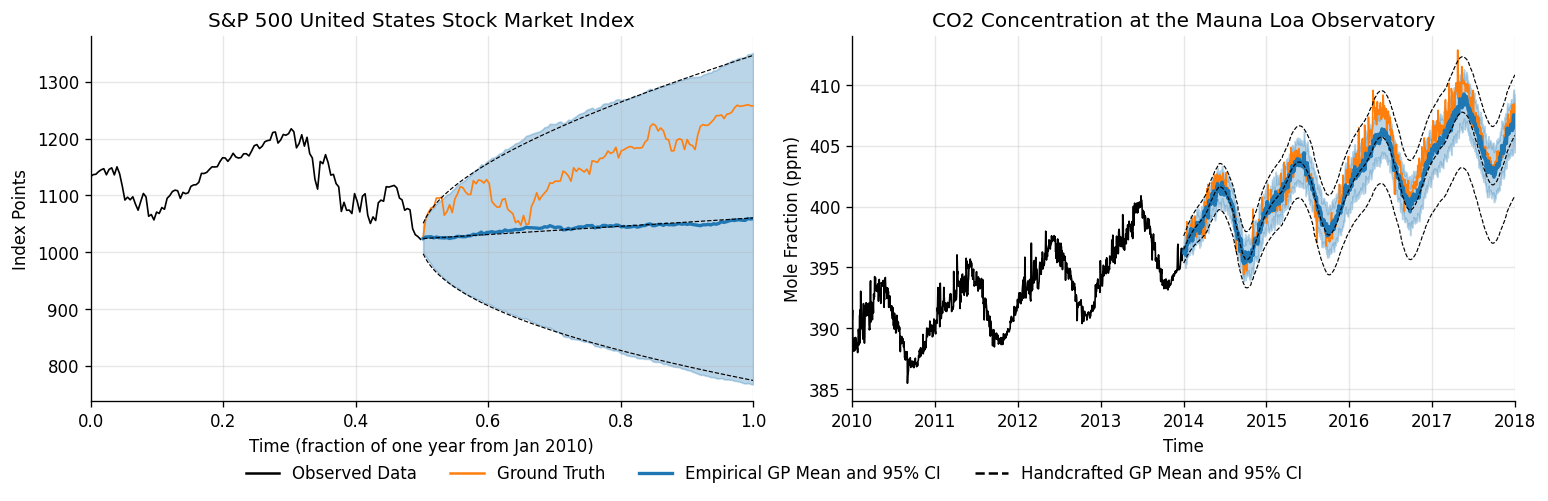

In [10]:
def plot_empirical(ax, X, preds, lw=2, color="tab:blue"):
    _, _, _, mean_test, std_test, _ = preds
    mean_test = np.asarray(mean_test)
    std_test = np.asarray(std_test)
    X = np.asarray(X).squeeze()
    ax.plot(X, mean_test, linewidth=lw, color=color)
    ax.fill_between(
        X,
        mean_test - 2 * std_test,
        mean_test + 2 * std_test,
        color=color,
        alpha=0.3,
    )


def plot_handcrafted(ax, X, preds, lw=0.7, color="k"):
    _, _, _, mean_test, std_test, _ = preds
    mean_test = np.asarray(mean_test)
    std_test = np.asarray(std_test)
    X = np.asarray(X).squeeze()
    ax.plot(X, mean_test, linewidth=lw, linestyle="--", color=color)
    ax.plot(X, mean_test - 2 * std_test, linewidth=lw, linestyle="--", color=color)
    ax.plot(X, mean_test + 2 * std_test, linewidth=lw, linestyle="--", color=color)


fig = plt.figure(figsize=(13, 4), dpi=120)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

for ax in [ax1, ax2]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)

lw = 1
# Financial panel
ax1.plot(np.asarray(train_X_f), np.asarray(train_Y_f), linewidth=lw, color="k")
ax1.plot(np.asarray(test_X_f), np.asarray(test_Y_f), linewidth=lw, color="tab:orange")
plot_empirical(ax1, test_X_f, empirical_preds_f)
plot_handcrafted(ax1, test_X_f, handcrafted_preds_f)
ax1.set_xlim([0, 1])
ax1.set_xlabel("Time (fraction of one year from Jan 2010)")
ax1.set_ylabel("Index Points")
ax1.set_title("S&P 500 United States Stock Market Index")

# Climate panel
ax2.plot(np.asarray(train_X_c), np.asarray(train_Y_c), linewidth=lw, color="k")
ax2.plot(np.asarray(test_X_c), np.asarray(test_Y_c), linewidth=lw, color="tab:orange")
plot_empirical(ax2, test_X_c, empirical_preds_c)
plot_handcrafted(ax2, test_X_c, handcrafted_preds_c)
ax2.set_xlim([0, 1])
ax2.set_xticks(np.linspace(0, 1, 9))
ax2.set_xticklabels([2010 + i for i in range(9)])
ax2.set_ylim([384, 414])
ax2.set_xlabel("Time")
ax2.set_ylabel("Mole Fraction (ppm)")
ax2.set_title("CO2 Concentration at the Mauna Loa Observatory")

custom_handles = [
    Line2D([0], [0], color="k", label="Observed Data"),
    Line2D([0], [0], color="tab:orange", label="Ground Truth"),
    Line2D([0], [0], color="tab:blue", label="Empirical GP Mean and 95% CI", lw=2),
    Line2D([0], [0], linestyle="--", color="k", label="Handcrafted GP Mean and 95% CI"),
]
fig.legend(
    handles=custom_handles,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    frameon=False,
)
fig.tight_layout()
plt.show()

Finally, we quantify forecast quality on the held-out horizon with the root-mean-squared error (RMSE) and the negative log-likelihood (NLL) under each model's predictive distribution.

In [11]:
def calculate_rmse_nll(mean, std, ground_truth):
    mean = np.asarray(mean)
    std = np.asarray(std)
    ground_truth = np.asarray(ground_truth)
    rmse = np.sqrt(mean_squared_error(ground_truth, mean))
    nll = -np.mean(norm.logpdf(ground_truth, loc=mean, scale=std))
    return rmse, nll


# Financial data
rmse_empirical_f, nll_empirical_f = calculate_rmse_nll(
    empirical_preds_f[3], empirical_preds_f[4], test_Y_f
)
rmse_handcrafted_f, nll_handcrafted_f = calculate_rmse_nll(
    handcrafted_preds_f[3], handcrafted_preds_f[4], test_Y_f
)

# Climate data
rmse_empirical_c, nll_empirical_c = calculate_rmse_nll(
    empirical_preds_c[3], empirical_preds_c[4], test_Y_c
)
rmse_handcrafted_c, nll_handcrafted_c = calculate_rmse_nll(
    handcrafted_preds_c[3], handcrafted_preds_c[4], test_Y_c
)

print(
    f"Financial  | Empirical GP:   RMSE = {rmse_empirical_f:8.4f}, "
    f"NLL = {nll_empirical_f:8.4f}"
)
print(
    f"Financial  | Handcrafted GP: RMSE = {rmse_handcrafted_f:8.4f}, "
    f"NLL = {nll_handcrafted_f:8.4f}"
)
print(
    f"Climate    | Empirical GP:   RMSE = {rmse_empirical_c:8.4f}, "
    f"NLL = {nll_empirical_c:8.4f}"
)
print(
    f"Climate    | Handcrafted GP: RMSE = {rmse_handcrafted_c:8.4f}, "
    f"NLL = {nll_handcrafted_c:8.4f}"
)

Financial  | Empirical GP:   RMSE = 122.6802, NLL =   6.1529
Financial  | Handcrafted GP: RMSE = 121.9282, NLL =   6.1540
Climate    | Empirical GP:   RMSE =   1.1168, NLL =   1.5485
Climate    | Handcrafted GP: RMSE =   1.4230, NLL =   1.6804
